# DINOv3 heatmap A/B — score modes and mask methods

A/B for the two knobs added to the detector (`fish_segmentation.dinov3`):

- **Score**: `mean` (original, 1 − average cosine similarity against the
  reference pool), `knn` (1 − mean of the top-k similarities) and **local
  contrast** (subtract a Gaussian-blurred copy of the score map). Local contrast
  flattens the broad warm halo around the hottest patches; a small sigma
  (~0.05) is for heatmap inspection, a large one (~0.25) survives the zoom
  recursion.
- **Mask**: `adaptive` (original: top percentile AND a local adaptive core,
  which can be empty on large frames) vs `hysteresis` (seeds at the top
  percentile grown through the lower-percentile connected region → one
  component per object instead of a fragmented core).

Runs on the tracked test media. Point `VIDEO_PATH` at a
`dataset/processed/<timestamp>_<hash>/video.mp4` for real footage.

Details: [dinov3.md](../docs/src/fish_segmentation/dinov3.md).

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

from fish_segmentation.dinov3 import (
    AnomalyOptions,
    ZOOM_LEVEL_COLORS,
    extract_salient_regions,
    load_backbone,
    remove_letterbox,
    run_dino_view,
    run_zoom_detector,
    segment_anomalies,
)
from fish_segmentation.paths import find_repo_root, load_env
from fish_segmentation.video_io import load_sampled_frames

load_env()
ROOT = find_repo_root()

device = "cuda" if torch.cuda.is_available() else "cpu"
DINO_LONG_SIDE = 1024
DINO_RESOLUTION_SCALE = 4.0

VIDEO_PATH = ROOT / "data" / "test_media" / "dolphin_00.mp4"
# VIDEO_PATH = ROOT / "dataset" / "processed" / "20260813_213529_7f994a2f" / "video.mp4"
print(device)

cuda


In [2]:
model_id = "facebook/dinov3-vitl16-pretrain-lvd1689m"
model, processor = load_backbone(model_id, device=device)

frames = load_sampled_frames(str(VIDEO_PATH), n_frames=3)
frame = remove_letterbox(frames[len(frames) // 2])
print(f"{VIDEO_PATH} — frame {frame.size[0]}x{frame.size[1]}")

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

/workspace/fish-segmentation/data/test_media/dolphin_00.mp4 — frame 1024x576


## 1. Heatmap: score modes and local contrast

Same scaled coarse view for every variant; the heatmap is min-max normalized to [0, 1] in all cases.

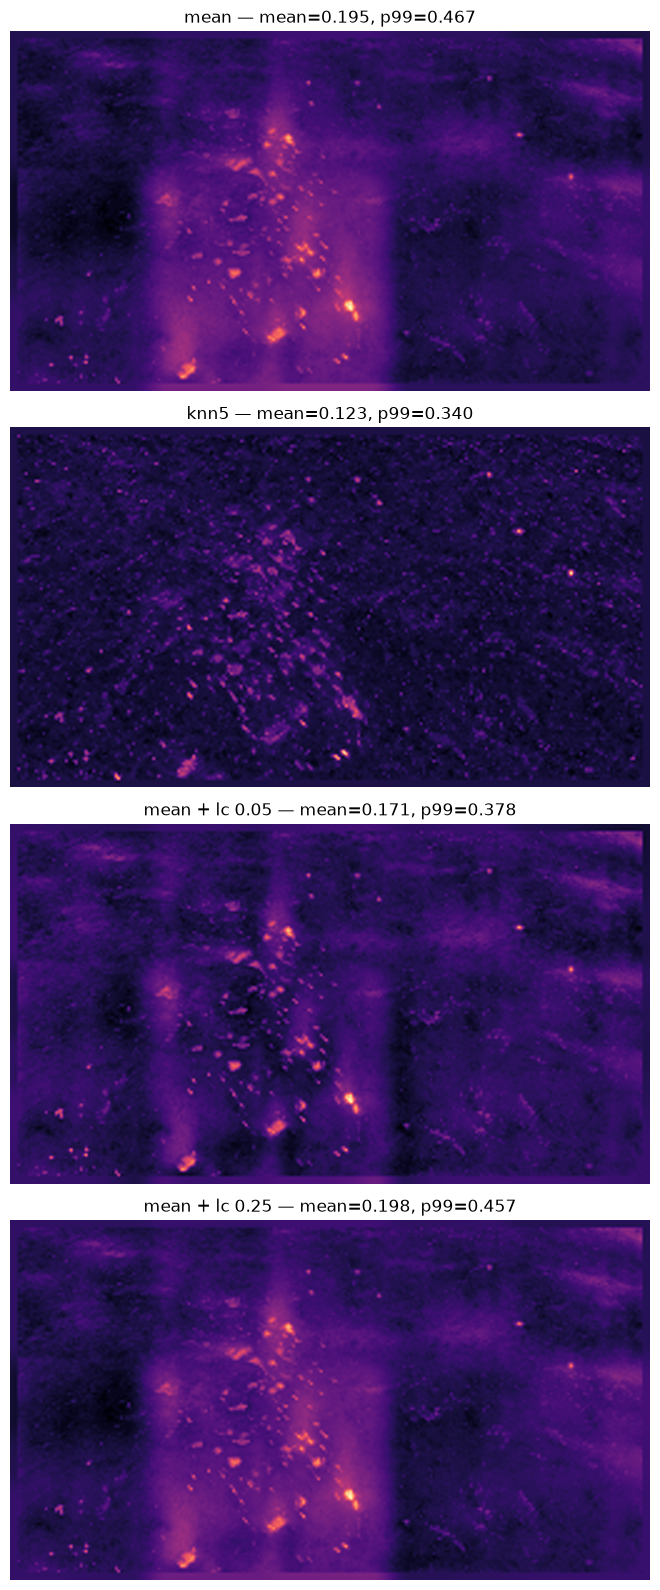

In [3]:
SCORE_VARIANTS = {
    "mean": AnomalyOptions(),
    "knn5": AnomalyOptions(score_mode="knn", knn_k=5),
    "mean + lc 0.05": AnomalyOptions(
        local_contrast_strength=1.0, local_contrast_sigma_pct=0.05
    ),
    "mean + lc 0.25": AnomalyOptions(
        local_contrast_strength=1.0, local_contrast_sigma_pct=0.25
    ),
}

fig, axes = plt.subplots(len(SCORE_VARIANTS), 1, figsize=(16, 4 * len(SCORE_VARIANTS)))
for ax, (name, opts) in zip(axes, SCORE_VARIANTS.items()):
    _, heat, _ = run_dino_view(
        frame, model, processor,
        long_side=DINO_LONG_SIDE, resolution_scale=DINO_RESOLUTION_SCALE,
        options=opts, device=device,
    )
    ax.imshow(heat, cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"{name} — mean={heat.mean():.3f}, p99={np.percentile(heat, 99):.3f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Mask: adaptive vs hysteresis

All masks use the same `mean` heatmap. `adaptive` is the legacy behavior; `hysteresis` grows the p99.5 seeds through the p98/p97 connected region.

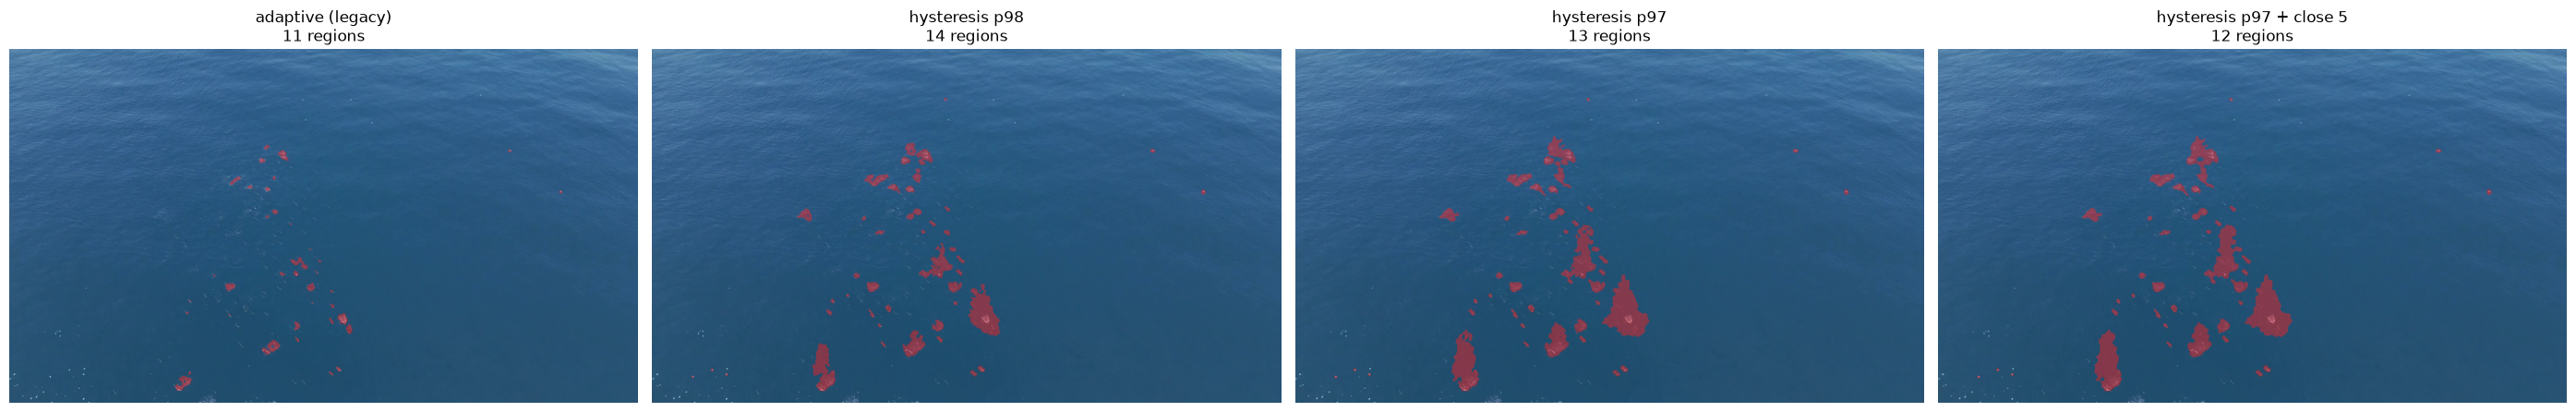

In [4]:
MASK_VARIANTS = {
    "adaptive (legacy)": dict(method="adaptive"),
    "hysteresis p98": dict(method="hysteresis", low_percentile=98.0),
    "hysteresis p97": dict(method="hysteresis", low_percentile=97.0),
    "hysteresis p97 + close 5": dict(
        method="hysteresis", low_percentile=97.0, closing_kernel_size=5
    ),
}

_, heat, _ = run_dino_view(
    frame, model, processor,
    long_side=DINO_LONG_SIDE, resolution_scale=DINO_RESOLUTION_SCALE,
    options=SCORE_VARIANTS["mean"], device=device,
)
base = np.asarray(frame.convert("RGB"))
fig, axes = plt.subplots(1, len(MASK_VARIANTS), figsize=(7 * len(MASK_VARIANTS), 4.5))
for ax, (name, kwargs) in zip(axes, MASK_VARIANTS.items()):
    mask = segment_anomalies(heat, percentile_threshold=99.5, **kwargs)
    _, regions = extract_salient_regions(mask, min_absolute_pixels=30)
    overlay = base.copy()
    overlay[mask > 0] = (255, 30, 30)
    ax.imshow(cv2.addWeighted(base, 0.55, overlay, 0.45, 0))
    ax.set_title(f"{name}\n{len(regions)} regions")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. End-to-end zoom detector

Merged detections per option set, colored by confirmation level. The validated defaults are `mean` + hysteresis p98; the legacy adaptive mask is kept for comparison.

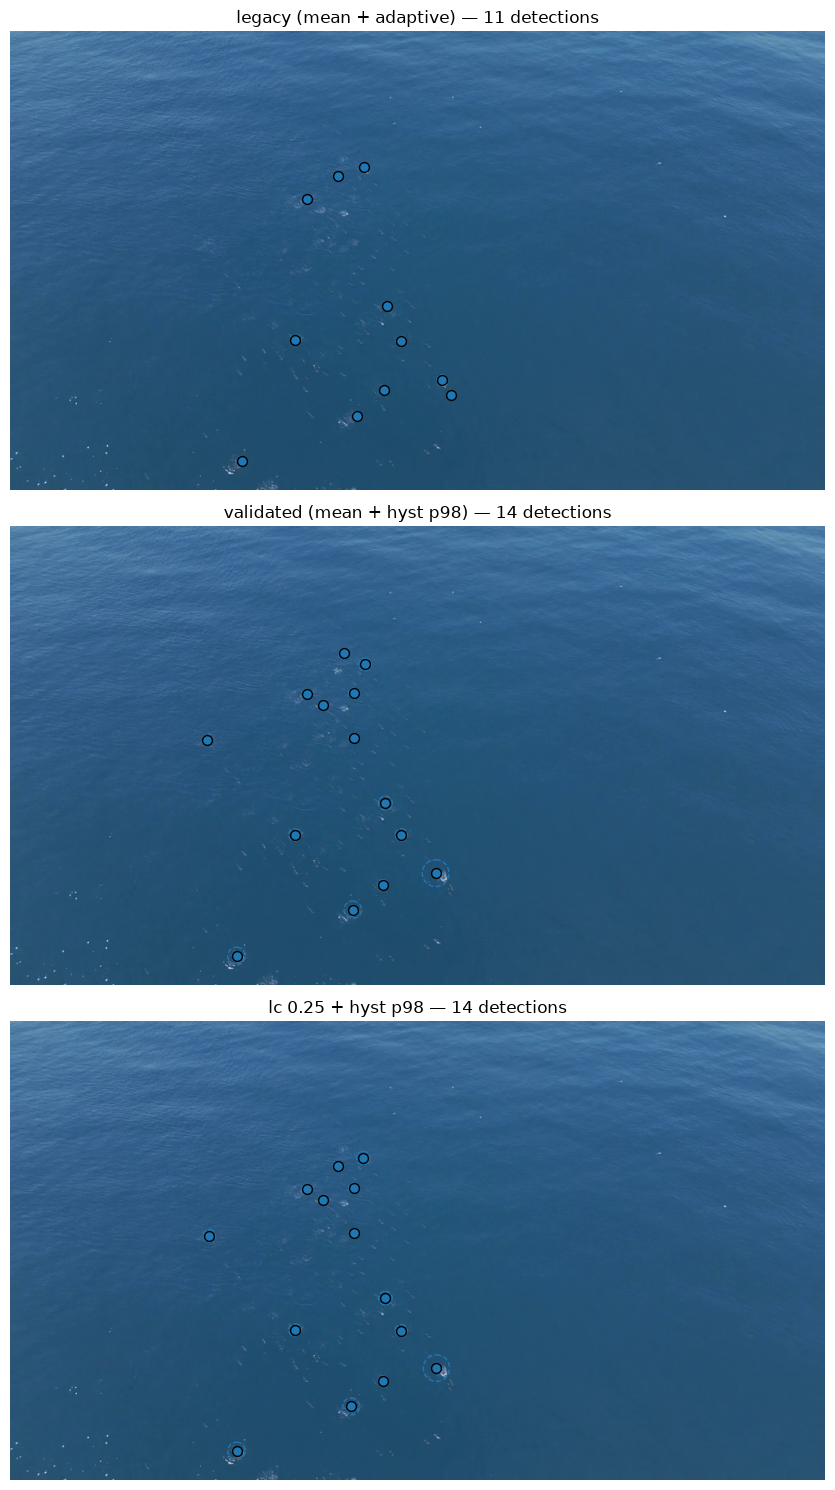

legacy (mean + adaptive)         detections= 11  radius(px)=[3, 6]  levels=[0]
validated (mean + hyst p98)      detections= 14  radius(px)=[5, 17]  levels=[0]
lc 0.25 + hyst p98               detections= 14  radius(px)=[5, 17]  levels=[0]


In [5]:
PIPELINE_VARIANTS = {
    "legacy (mean + adaptive)": AnomalyOptions(mask_method="adaptive"),
    "validated (mean + hyst p98)": AnomalyOptions(),
    "lc 0.25 + hyst p98": AnomalyOptions(
        local_contrast_strength=1.0, local_contrast_sigma_pct=0.25
    ),
}

results = {}
fig, axes = plt.subplots(len(PIPELINE_VARIANTS), 1, figsize=(16, 5 * len(PIPELINE_VARIANTS)))
for ax, (name, opts) in zip(axes, PIPELINE_VARIANTS.items()):
    detections = run_zoom_detector(
        image=frame, model=model, processor=processor,
        long_side=DINO_LONG_SIDE, resolution_scale=DINO_RESOLUTION_SCALE,
        merge_gap=0.08, min_zone_fraction=0.25, options=opts,
    )
    results[name] = detections

    W, H = frame.size
    ax.imshow(frame)
    for det in detections:
        color = ZOOM_LEVEL_COLORS[det["level"] % len(ZOOM_LEVEL_COLORS)]
        cx, cy, radius = det["x"] * W, det["y"] * H, det["radius"] * max(W, H)
        ax.scatter(cx, cy, c=color, edgecolors="black", s=50, zorder=5)
        ax.add_patch(
            plt.Circle((cx, cy), radius, color=color, fill=False, linestyle="--", linewidth=1.0)
        )
    ax.set_title(f"{name} — {len(detections)} detections")
    ax.axis("off")
plt.tight_layout()
plt.show()

for name, detections in results.items():
    radii = [d["radius"] * max(frame.size) for d in detections]
    levels = sorted({d["level"] for d in detections})
    print(
        f"{name:32s} detections={len(detections):3d}  "
        f"radius(px)=[{min(radii, default=0):.0f}, {max(radii, default=0):.0f}]  levels={levels}"
    )